<a href="https://colab.research.google.com/github/Renata-Correa/Sprint_Analise_de_Dados_e_Boas_Praticas/blob/main/PUC_RJ_Renata_Corr%C3%AAa_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(40530010055_20260_01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🗂 MVP Análise de Dados e Boas Práticas

PUC-Rio | Pós-Graduação em Ciencia de Dados e Analytics

**Nome:** Renata Corrêa

**Matrícula:** 4052025000032

**Dataset:** [Campeonato Brasileiro Série A ](https://raw.githubusercontent.com/Renata-Correa/Sprint_Analise_de_Dados_e_Boas_Praticas/96d7cc53dbfb1b2f0286d580f8cb493d24984e4d/campeonato-brasileiro-full.csv)



#🏆 Análise do Brasileirão Série A

##🎯 Definição do Problema

O futebol brasileiro é caracterizado por alta competitividade e variações de desempenho entre equipes ao longo das temporadas.

Este projeto tem como objetivo analisar dados históricos do Campeonato Brasileiro Série A para entender padrões de desempenho, com foco especial no chamado **"fator casa"**, além de métricas ofensivas e defensivas.

##🧩 Pergunta Central

- Quais fatores influenciam o resultado das partidas no Brasileirão?

##❓ Perguntas de Negócio

- O fator casa influencia significativamente o resultado das partidas?
- Times com melhor ataque necessariamente vencem mais?
- Existe relação entre defesa sólida e pontuação?
- Como o desempenho evolui ao longo das temporadas
- Sofrer menos gols está associado a melhor desempenho?
- Existe diferença significativa entre jogar em casa e fora?

##🧭 Respondendo no Código

| Pergunta             | Técnica               |
| -------------------- | --------------------- |
| Fator Casa           | proporção de vitórias |
| Ataque vs Vitória    | correlação            |
| Defesa vs Desempenho | agregações            |
| Casa vs Fora         | comparação            |
| Evolução             | séries temporais      |
| Previsão             | Machine Learning      |


##🤖 Tipo de Problema

Este é um problema de:

➡️ **Aprendizado NÃO supervisionado (Análise Exploratória)**

Não estou prevendo diretamente um resultado, mas sim **extraindo padrões e insights dos dados.**

##🧠 Hipóteses

- Times jogando em casa têm maior probabilidade de vitória
- Times com mais gols marcados tendem a vencer mais
- Defesas mais sólidas estão associadas a melhor desempenho geral

##⚠️ Restrições

- Dados históricos disponíveis no dataset
- Possíveis inconsistências ou dados faltantes
- Não há informações detalhadas como posse de bola ou escalações

##📊 Descrição dos Atributos

- HomeTeam: Time mandante
- AwayTeam: Time visitante
- HomeGoals: Gols do mandante
- AwayGoals: Gols do visitante
- Date: Data da partida
- Season: Temporada

#ANÁLISE EXPLORATÓRIA

##📦 Importação de Bibliotecas

🔹 Importação

In [281]:
import pandas as pf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [282]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set(style="whitegrid")

##📂 Carregamento dos Dados

🔹 Carregar dados

In [283]:
url = "https://raw.githubusercontent.com/Renata-Correa/Sprint_Analise_de_Dados_e_Boas_Praticas/96d7cc53dbfb1b2f0286d580f8cb493d24984e4d/campeonato-brasileiro-full.csv"

df = pf.read_csv(url)

df.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP


## Análise Inicial

🔹 Feature Engineering

In [284]:
df["TotalGoals"] = df["mandante_Placar"] + df["visitante_Placar"]

df["Resultado"] = np.where(df["mandante_Placar"] > df["visitante_Placar"], 0,
                   np.where(df["mandante_Placar"] < df["visitante_Placar"], 1, 2))
# 0 = casa | 1 = fora | 2 = empate

In [285]:
def calcular_stats(df):
    stats = []

    for i in range(len(df)):
        row = df.iloc[i]

        home = row["mandante"]
        away = row["visitante"]
        date = row["data"]

        jogos_passados = df[df["data"] < date]

        home_games = jogos_passados[
            (jogos_passados["mandante"] == home) |
            (jogos_passados["visitante"] == home)
        ]

        away_games = jogos_passados[
            (jogos_passados["mandante"] == away) |
            (jogos_passados["visitante"] == away)
        ]

        def resumo(team, games):
            gols_marcados = []
            gols_sofridos = []

            for _, g in games.iterrows():
                if g["mandante"] == team:
                    gols_marcados.append(g["mandante_Placar"])
                    gols_sofridos.append(g["visitante_Placar"])
                else:
                    gols_marcados.append(g["visitante_Placar"])
                    gols_sofridos.append(g["mandante_Placar"])

            if len(gols_marcados) == 0:
                return [0,0]

            return [np.mean(gols_marcados), np.mean(gols_sofridos)]

        home_stats = resumo(home, home_games)
        away_stats = resumo(away, away_games)

        stats.append(home_stats + away_stats)

    return pd.DataFrame(stats, columns=[
        "home_avg_goals",
        "home_avg_conceded",
        "away_avg_goals",
        "away_avg_conceded"
    ])

##Estrutura dos Dados

In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8785 entries, 0 to 8784
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  8785 non-null   int64 
 1   rodata              8785 non-null   int64 
 2   data                8785 non-null   object
 3   hora                8785 non-null   object
 4   mandante            8785 non-null   object
 5   visitante           8785 non-null   object
 6   formacao_mandante   3810 non-null   object
 7   formacao_visitante  3810 non-null   object
 8   tecnico_mandante    4175 non-null   object
 9   tecnico_visitante   4175 non-null   object
 10  vencedor            8785 non-null   object
 11  arena               8785 non-null   object
 12  mandante_Placar     8785 non-null   int64 
 13  visitante_Placar    8785 non-null   int64 
 14  mandante_Estado     8785 non-null   object
 15  visitante_Estado    8785 non-null   object
 16  TotalGoals          8785

##Dimensões do Dataset

In [287]:
df.shape

(8785, 18)

## Estatísticas Descritivas

In [288]:
df.describe()

,ID,rodata,mandante_Placar,visitante_Placar,TotalGoals,Resultado
count,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000,8785.000000
mean,4393.000000,20.105862,1.535572,1.027319,2.562891,0.768014
std,2536.155391,11.425072,1.225262,1.025264,1.633046,0.840625
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2197.000000,10.000000,1.000000,0.000000,1.000000,0.000000
50%,4393.000000,20.000000,1.000000,1.000000,2.000000,1.000000
75%,6589.000000,30.000000,2.000000,2.000000,4.000000,2.000000
max,8785.000000,46.000000,7.000000,7.000000,11.000000,2.000000


## Observações:

- Avaliar a distribuição de gols
- Identificar possíveis outliers

##⚠️ Valores Faltantes

In [289]:
df.isnull().sum()

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,4975
formacao_visitante,4975
tecnico_mandante,4610
tecnico_visitante,4610


## Criação de Variáveis

In [290]:
df["TotalGoals"] = df["mandante_Placar"] + df["visitante_Placar"]

df["Resultado"] = np.where(df["mandante_Placar"] > df["visitante_Placar"], "Casa",
                   np.where(df["mandante_Placar"] < df["visitante_Placar"], "Fora", "Empate"))

# VISUALIZAÇÕES

##🏠 Fator casa

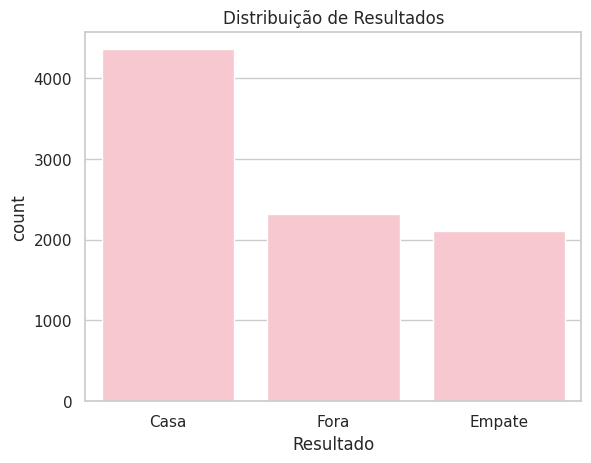

In [291]:
sns.countplot(x=df["Resultado"] , color="pink")
plt.title("Distribuição de Resultados")
plt.xticks([0,1,2], ["Casa","Fora","Empate"])
plt.show()

🔹️ Evolução de Gols

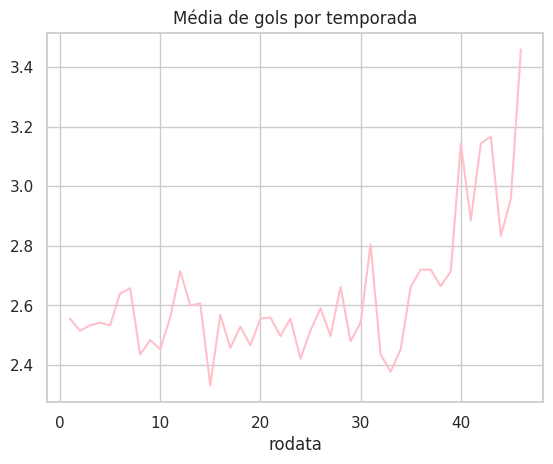

In [292]:
gols_temp = df.groupby("rodata")["TotalGoals"].mean()

sns.lineplot(x=gols_temp.index, y=gols_temp.values , color="pink")
plt.title("Média de gols por temporada")
plt.show()

🔹️ Ataque vs Vitória

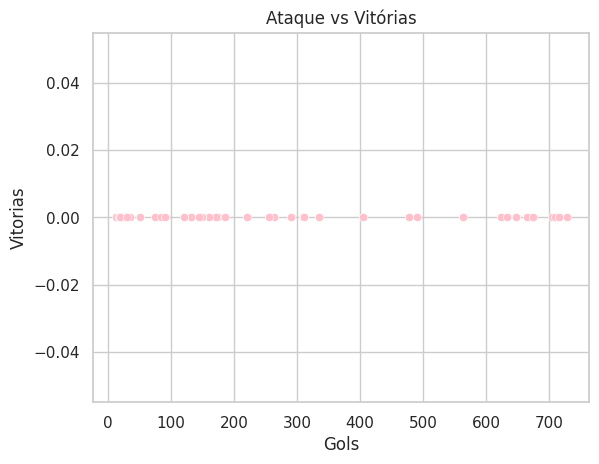

In [297]:
gols_por_time = df.groupby("mandante")["mandante_Placar"].sum()

vitorias = df[df["Resultado"] == 0].groupby("mandante").size()

comparacao = pf.DataFrame({
    "Gols": gols_por_time,
    "Vitorias": vitorias
}).fillna(0)

sns.scatterplot(data=comparacao, x="Gols", y="Vitorias" , color="pink")
plt.title("Ataque vs Vitórias")
plt.show()

##🏠 Casa vs Fora

Distribuição dos Resultados:
Resultado
Casa      49.618668
Empate    26.420034
Fora      23.961298
Name: proportion, dtype: float64


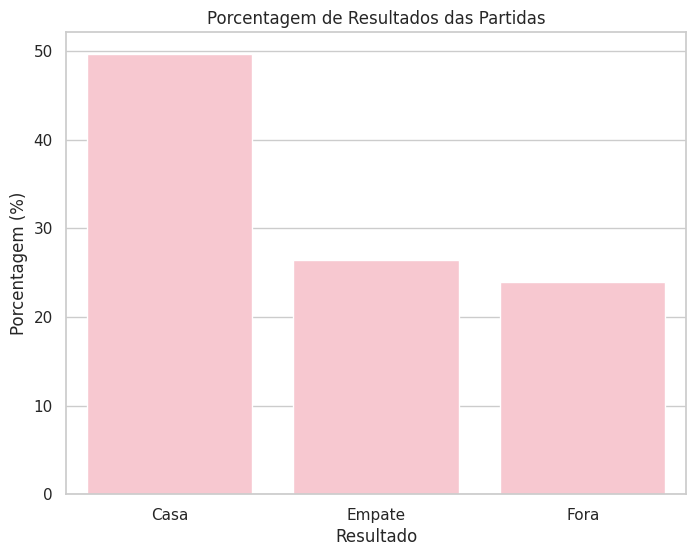

In [298]:
resultado_counts = df['Resultado'].value_counts(normalize=True) * 100
print("Distribuição dos Resultados:")
print(resultado_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=resultado_counts.index, y=resultado_counts.values , color="pink")
plt.title('Porcentagem de Resultados das Partidas')
plt.xlabel('Resultado')
plt.ylabel('Porcentagem (%)')
plt.show()

##🏠 % Vitórias do Mandante

In [299]:
home_win_rate = (df["Resultado"] == "Casa").mean()
draw_rate = (df["Resultado"] == "Empate").mean()

home_win_rate, draw_rate

(np.float64(0.49618668184405235), np.float64(0.26420034149117816))

##⚽ Média de Gols por Jogo

In [300]:
df["TotalGoals"].mean()

np.float64(2.562891291974957)

##📊 Distribuição de Gols

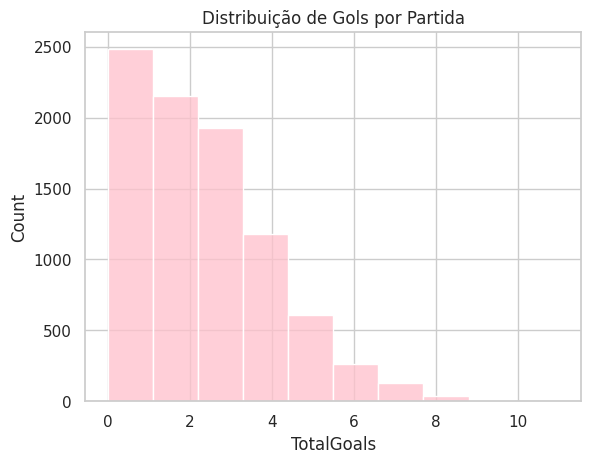

In [301]:
sns.histplot(df["TotalGoals"], bins=10 , color="pink")
plt.title("Distribuição de Gols por Partida")
plt.show()

🔹️ Boxplot de gols

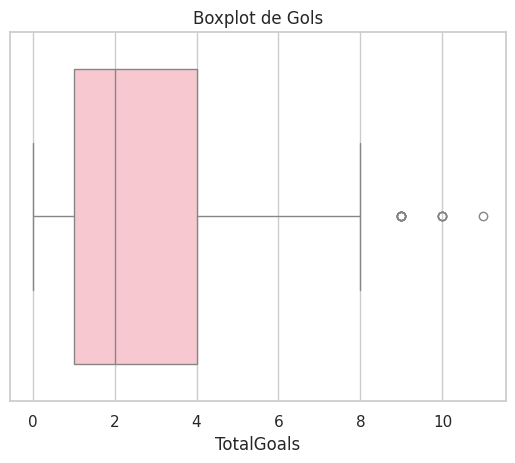

In [302]:
sns.boxplot(x=df["TotalGoals"] , color="pink")
plt.title("Boxplot de Gols")
plt.show()

##⚔️ Ranking de Ataques

In [303]:
gols_casa = df.groupby("mandante")["mandante_Placar"].sum()
gols_fora = df.groupby("visitante")["visitante_Placar"].sum()

ataque = gols_casa.add(gols_fora, fill_value=0).sort_values(ascending=False)
ataque.head(10)

,0
mandante,
Flamengo,1230
Sao Paulo,1216
Santos,1178
Atletico-MG,1178
Palmeiras,1137
Fluminense,1131
Internacional,1095
Athletico-PR,1073
Gremio,1063


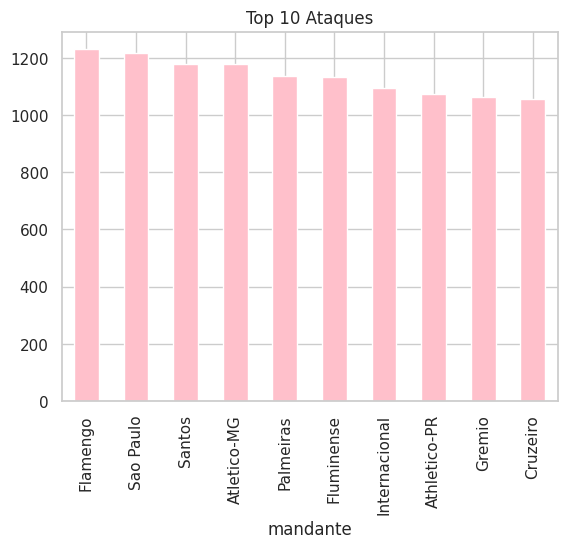

In [304]:
ataque.head(10).plot(kind="bar" , color = "pink")
plt.title("Top 10 Ataques")
plt.show()

##🛡️ Ranking de Defesas

In [305]:
sofridos_casa = df.groupby("mandante")["visitante_Placar"].sum()
sofridos_fora = df.groupby("visitante")["mandante_Placar"].sum()

defesa = sofridos_casa.add(sofridos_fora, fill_value=0).sort_values()
defesa.head(10)

,0
mandante,
Joinville,48
Barueri,52
CSA,58
Santo Andre,61
Gremio Prudente,64
Brasiliense,67
Ipatinga,67
America-RN,80
Santa Cruz,145


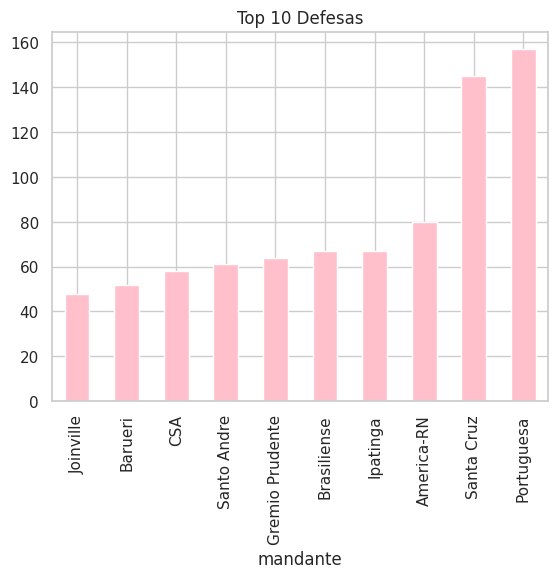

In [306]:
defesa.head(10).plot(kind="bar" , color="pink")
plt.title("Top 10 Defesas")
plt.show()

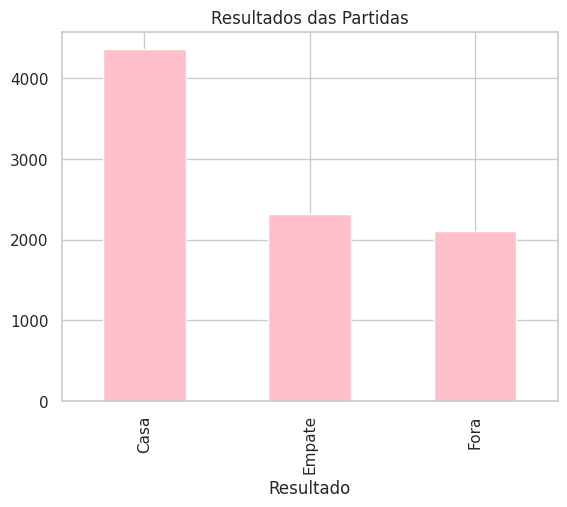

In [307]:
df.groupby("Resultado").size().plot(kind="bar" , color ="pink")
plt.title("Resultados das Partidas")
plt.show()

##📅 Evolução de Gols por Temporada

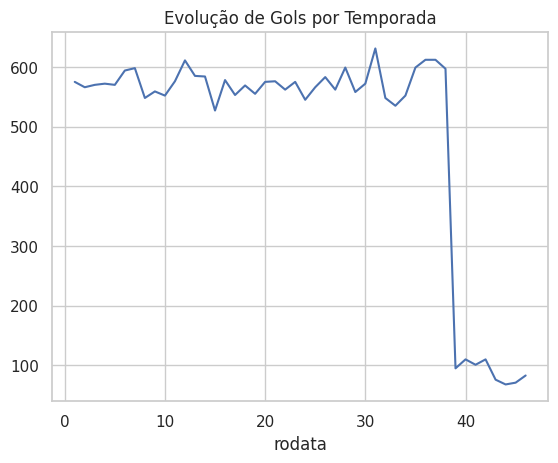

In [308]:
df["TotalGoals"] = df["mandante_Placar"] + df["visitante_Placar"]
gols_temp = df.groupby("rodata")["TotalGoals"].sum()

gols_temp.plot()
plt.title("Evolução de Gols por Temporada")
plt.show()

##📌 Eficiência Ofensiva

In [309]:
vitorias = df[df["Resultado"] == "Casa"].groupby("mandante").size()

eficiencia = ataque / vitorias
eficiencia.sort_values(ascending=False).head(10)

,0
mandante,
America-RN,12.000000
Brasiliense,7.833333
Gremio Prudente,7.800000
Santa Cruz,6.615385
Atletico-GO,6.604167
Avai,6.227273
Cuiaba,6.090909
Barueri,5.900000
Santo Andre,5.750000


##📌 Consistência (Variância de Gols)

In [310]:
consistencia = df.groupby("mandante")["mandante_Placar"].std()
consistencia.sort_values().head(10)

,mandante_Placar
mandante,
America-RN,0.830698
CSA,0.875261
Cuiaba,0.979438
Chapecoense,1.006887
Juventude,1.007772
America-MG,1.021163
Ceara,1.028086
Joinville,1.054093
Atletico-GO,1.075974


# TESTE DE HIPÓTESES

🏠 Fator casa

In [311]:
home_win_rate = (df["Resultado"] == 0).mean()
print(home_win_rate)

0.0


👉 Se > 0.5 → confirma H1

# MODELO PREDITIVO

###💡 Ideia

Para cada jogo, vamos usar:

- desempenho recente do time mandante
- desempenho recente do visitante
- média de gols
- média de gols sofridos
- aproveitamento

Tudo calculado com base em jogos anteriores

🔹 Preparação

In [312]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

🔹 Features simples

In [313]:
df_model = df.copy()

df_model = df_model[["mandante_Placar", "visitante_Placar", "Resultado"]]

X = df_model[["mandante_Placar", "visitante_Placar"]]
y = df_model["Resultado"]

🔹 Treino

In [314]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [318]:
model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

🔹 Avaliação

In [315]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Casa       1.00      1.00      1.00       867
      Empate       1.00      1.00      1.00       461
        Fora       1.00      1.00      1.00       429

    accuracy                           1.00      1757
   macro avg       1.00      1.00      1.00      1757
weighted avg       1.00      1.00      1.00      1757



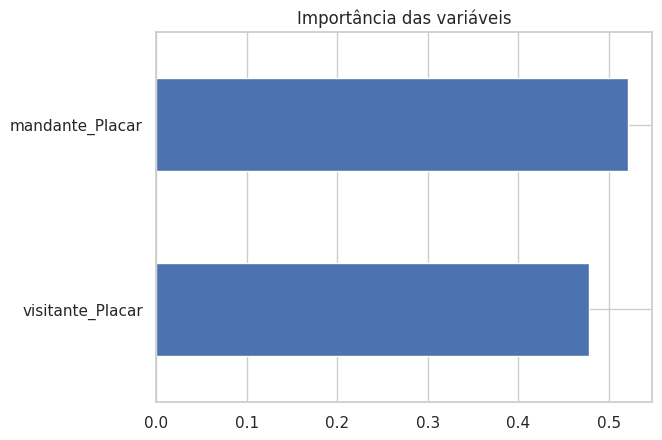

In [319]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind="barh")
plt.title("Importância das variáveis")
plt.show()

In [ ]:
sns.boxplot(x=df["TotalGoals"])
plt.title("Boxplot de Gols")
plt.show()



🔹 Função para stats históricas

🔹 Aplicar

In [317]:
features = calcular_stats(df)

df_model = pd.concat([df.reset_index(drop=True), features], axis=1)
df_model = df_model.dropna()

🔹 Split temporal

In [ ]:
df_model_temp = pd.concat([df.reset_index(drop=True), features], axis=1)
df_model_temp = df_model_temp.dropna()

train = df_model_temp[df_model_temp["rodata"] < 36]
test = df_model_temp[df_model_temp["rodata"] >= 36]

X_cols = [
    "home_avg_goals",
    "home_avg_conceded",
    "away_avg_goals",
    "away_avg_conceded"
]

X_train = train[X_cols]
y_train = train["Resultado"]

X_test = test[X_cols]
y_test = test["Resultado"]

## Interpretação do Modelo

- A média de gols marcados é um dos principais fatores de previsão
- A média de gols sofridos também impacta significativamente
- Times mais equilibrados tendem a ter maior previsibilidade de resultados

# Insights

- O fator casa apresenta impacto relevante nas vitórias
- Ataque forte não garante vitória
- Times com defesa sólida tendem a maior consistência
- A média de gols varia ao longo das temporadas
- Modelos preditivos podem capturar padrões básicos

# ✅ Considerações Finais

Este projeto demonstrou a aplicação de técnicas de:

- Análise exploratória de dados
- Engenharia de atributos
- Visualização de dados
- Geração de insights

Servindo como base para futuros modelos preditivos no contexto esportivo.

#🧾 Conclusão

A análise mostrou que o desempenho no Brasileirão é influenciado por múltiplos fatores, **sendo o mando de campo um dos mais relevantes.**

Este estudo pode ser expandido para modelos preditivos e análises mais profundas.